# Complexidade Técnico-Linguística de Termos Médicos do SUS
## Construção do dataset — passo a passo

**Ciência de Dados — IFPB/PPGTI — 2026.1**
Docentes: Damires Souza e Alex Cunha · Equipe: Lucas Matheus Santos da Silva, Pedro Ivo Santos Leite

Este notebook constrói, passo a passo, um **dataset rotulado** que classifica diagnósticos (CID-10) e procedimentos (SIGTAP) do SUS em três níveis de **complexidade técnico-linguística**: baixa, média ou alta. Cada etapa tem uma explicação simples antes do código. Pedro

### O pipeline de construção do dataset

Seguimos as etapas previstas no planejamento do projeto:

| # | Etapa | O que faz |
|---|---|---|
| 1 | **Coleta** | baixar e ler as fontes oficiais (CID-10, SIGTAP) |
| 2 | **Integração** | juntar as fontes numa só tabela |
| 3 | **Limpeza** | tratar vazios e duplicidades |
| 4 | **Atributos** | extrair características do texto |
| 5 | **Rotulagem** | classificação heurística da complexidade (`score`) |
| 6 | **Análise** | exploração, visualização e outliers |
| 7 | **Modelagem** | árvore de decisão + avaliação |

> Só usamos **dados públicos e secundários** (DataSUS). Nenhum dado de paciente.

## Etapa 1 — Coleta dos dados

### 1.1 Preparar o ambiente
Importamos as bibliotecas (as "caixas de ferramentas"): **pandas** (tabelas), **numpy** (números), **re** (busca em texto), **matplotlib/seaborn** (gráficos), **sklearn** (árvore de decisão).

In [1]:
import pandas as pd
import numpy as np
import re
import zipfile, glob
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Ambiente pronto!")

Ambiente pronto!


In [ ]:
# (Opcional) Montagem do Google Drive — não é mais necessária,
# pois os dados são lidos direto do repositório no GitHub.
# from google.colab import drive
# drive.mount('/content/drive')

### 1.2 Carregar os diagnósticos (CID-10)
A CID-10 é a tabela oficial de **doenças/diagnósticos**, num arquivo CSV. Lemos com `sep=";"` (colunas separadas por ponto-e-vírgula) e `encoding="latin-1"` (codificação dos acentos).

In [2]:
# Lê direto do repositório no GitHub (não precisa fazer upload no Colab)
URL_CID = "https://raw.githubusercontent.com/L42Matheus/mpti_cd_final-projeto/main/dados/CID10/tb_cid.txt"

cid = pd.read_fwf(URL_CID, widths=[4, 100],
                  names=["codigo", "descricao"], dtype=str, encoding="latin-1")
cid["descricao"] = cid["descricao"].str.strip()

# Mantém só subcategorias (códigos de 4 dígitos), pra ter o mesmo nível de detalhe
cid = cid[cid["codigo"].str.len() == 4].reset_index(drop=True)

cid["fonte"] = "CID-10"
print("Diagnósticos carregados:", len(cid))
cid.head()

Diagnósticos carregados: 12198


,codigo,descricao,fonte
0,A000,"Cólera devida a Vibrio Cholerae 01, biótipo Ch...",CID-10
1,A001,"Cólera devida a Vibrio Cholerae 01, biótipo El...",CID-10
2,A009,Cólera não especificada,CID-10
3,A010,Febre tifóide,CID-10
4,A011,Febre paratifóide A,CID-10


### 1.3 Carregar os procedimentos (SIGTAP)
O SIGTAP é a tabela oficial de **procedimentos**, distribuída num pacote `.zip` (a "competência" do mês). O arquivo é de **largura fixa**: não tem separador, cada informação ocupa posições certas na linha. Por isso usamos `read_fwf` informando as larguras (10 = código, 250 = descrição).

In [3]:
URL_SIGTAP = "https://raw.githubusercontent.com/L42Matheus/mpti_cd_final-projeto/main/dados/SIGTAP/tb_procedimento.txt"

sig = pd.read_fwf(URL_SIGTAP,
                  widths=[10, 250], names=["codigo", "descricao"],
                  dtype=str, encoding="latin-1")
sig["descricao"] = sig["descricao"].str.strip()
sig["fonte"] = "SIGTAP"

print("Procedimentos carregados:", len(sig))
sig.head()

Procedimentos carregados: 4984


,codigo,descricao,fonte
0,0101010010,ATIVIDADE EDUCATIVA / ORIENTAÇÃO EM GRUPO NA A...,SIGTAP
1,0101010028,ATIVIDADE EDUCATIVA / ORIENTAÇÃO EM GRUPO NA A...,SIGTAP
2,0101010036,PRÁTICA CORPORAL / ATIVIDADE FÍSICA EM GRUPO,SIGTAP
3,0101010095,PREVENÇÃO DA COVID-19 NAS ESCOLAS,SIGTAP
4,0101010109,ATIVIDADES EDUCATIVAS DA POPULAÇÃO SOBRE A TEM...,SIGTAP


## Etapa 2 — Integração das fontes

Colocamos as duas tabelas **uma embaixo da outra** (`concat`). Ficamos com um único conjunto de descrições, cada uma sabendo sua origem pela coluna `fonte`.

> Tratamos CID-10 e SIGTAP como **duas fontes de texto independentes** — o objetivo é medir a linguagem, não ligar doença a procedimento.

In [4]:
df = pd.concat([cid, sig], ignore_index=True)
print("Total de registros:", len(df))
print(df["fonte"].value_counts())
df.sample(5)

Total de registros: 17182
fonte
CID-10    12198
SIGTAP     4984
Name: count, dtype: int64


,codigo,descricao,fonte
6469,Q674,"Outras deformidades congênitas do crânio, da f...",CID-10
2876,H502,Estrabismo vertical,CID-10
303,A779,Febre maculosa não especificada,CID-10
10367,X462,Envenen. acid. por expos. a solv. org./hidroca...,CID-10
1290,D177,Neoplasia lipomatosa benigna de outras localiz...,CID-10


## Etapa 3 — Limpeza dos dados

Garantimos qualidade tratando dois problemas comuns em bases oficiais:
- **Valores ausentes** (descrições vazias ou nulas);
- **Duplicidades semânticas** (mesma descrição aparecendo com códigos diferentes).

> **Por que não usar `codigo + descricao`?** Os códigos da CID-10 e do SIGTAP são únicos por natureza — checar duplicidade incluindo o código sempre devolve 0. Para o nosso objetivo (medir linguagem), o que interessa é a **descrição repetida**: quando o mesmo texto aparece sob códigos diferentes (frequente no SIGTAP, em formas organizacionais distintas), ele inflaria a contagem de uma mesma frase. Por isso o `subset` é apenas `descricao`.

In [5]:
antes = len(df)

# Valores ausentes
ausentes = df["descricao"].isna().sum()
print("Descrições ausentes (nulas):", ausentes)
df = df[df["descricao"].notna()]
df = df[df["descricao"].str.len() > 0]

# Duplicidades semânticas: mesma descrição com códigos diferentes.
# Códigos são únicos por natureza — checar (codigo, descricao) sempre daria 0.
duplicados = df.duplicated(subset=["descricao"]).sum()
print("Descrições duplicadas:", duplicados)
df = df.drop_duplicates(subset=["descricao"]).reset_index(drop=True)

print(f"\nAntes: {antes}  ->  Depois: {len(df)} registros")
df.head()

Descrições ausentes (nulas): 0
Descrições duplicadas: 21

Antes: 17182  ->  Depois: 17161 registros


,codigo,descricao,fonte
0,A000,"Cólera devida a Vibrio Cholerae 01, biótipo Ch...",CID-10
1,A001,"Cólera devida a Vibrio Cholerae 01, biótipo El...",CID-10
2,A009,Cólera não especificada,CID-10
3,A010,Febre tifóide,CID-10
4,A011,Febre paratifóide A,CID-10


## Etapa 4 — Extração de atributos do texto

Para cada descrição, medimos **7 características** que indicam a dificuldade do texto:

| Atributo | O que mede |
|---|---|
| `qtd_palavras` | quantas palavras tem |
| `qtd_caracteres` | quantas letras tem |
| `qtd_palavras_longas` | quantas palavras têm ≥12 caracteres |
| `qtd_sinais_morfologicos` | quantos sinais greco-latinos (`-ite`, `-ectomia`, `cardio-`…) |
| `qtd_termos_decs` | quantos termos do vocabulário **DeCS** aparecem na descrição |
| `tem_sigla` | tem sigla conhecida do SUS? (0 ou 1) |
| `tem_abreviacao` | tem abreviação? (0 ou 1) |

> O **DeCS** (Descritores em Ciências da Saúde — BIREME/BVS) é o vocabulário controlado oficial da área de saúde. Usamos o XML em português como **tabela de consulta**: cada descrição é varrida e contamos quantas expressões do DeCS aparecem nela. É o atributo principal de jargão médico, substituindo o proxy morfológico que usávamos antes.

### 4.1 Como reconhecer um "termo técnico"
Não dá para listar todos os termos médicos. Usamos um truque da própria medicina: termos médicos têm **pedaços gregos e latinos** (ex.: *-ite* = inflamação, *-ectomia* = remoção, *-scopia* = exame visual). Base: Rezende (2004). Se a palavra contém um desses pedaços (ou é muito longa), é técnica.

In [7]:
# Morfemas greco-latinos típicos da linguagem médica (Rezende, 2004)
MORFEMAS = ["ite", "ose", "emia", "patia", "ectomia", "tomia", "plastia",
            "scopia", "grafia", "algia", "oma", "cardio", "gastro", "hepato",
            "nefro", "neuro", "osteo", "artro", "pneumo", "hemo", "vascul",
            "carcinom", "neoplas", "metast", "trombo", "isquem"]

COMUNS = {"de","da","do","e","ou","com","sem","para","por","em","nao",
          "outras","outros","especificada","especificado"}

LIMITE_PALAVRA_LONGA = 12

def tem_sinal_morfologico(palavra):
    """True se a palavra contém um morfema greco-latino médico."""
    p = palavra.lower()
    if p in COMUNS or len(p) < 4:
        return False
    return any(m in p for m in MORFEMAS)

def eh_palavra_longa(palavra):
    """True se a palavra tem >= LIMITE_PALAVRA_LONGA caracteres (somente descritivo)."""
    return len(palavra) >= LIMITE_PALAVRA_LONGA

# Demonstração
for palavra in ["asma", "broncodilatador", "gastrite", "tratamento", "de"]:
    print(f"{palavra:18} morfo={tem_sinal_morfologico(palavra)}  longa={eh_palavra_longa(palavra)}")

asma               morfo=False  longa=False
broncodilatador    morfo=False  longa=True
gastrite           morfo=True  longa=False
tratamento         morfo=False  longa=False
de                 morfo=False  longa=False


### 4.2 Detectar siglas e abreviações
- **Sigla**: duas ou mais letras maiúsculas seguidas (SUS, OPM).
- **Abreviação**: padrões como "não espec." ou palavras curtas com ponto.

In [8]:
# Lista auditável de siglas comuns no SUS / saúde.
# Vale lembrar: SIGTAP vem em CAIXA ALTA, então regex de maiúsculas geraria muitos falsos positivos.
SIGLAS_SUS = {
    "SUS","OPM","NASF","AIDS","HIV","HPV","DPOC","AVC","IAM","HAS",
    "DM","DST","IST","TGI","ITU","ICC","CA","RX","TC","RM",
    "ECG","EEG","UTI","UPA","ESF","PSF","RN","SVD","BCG","DTPA",
    "CIPE","CID","TARV","PNI","PEP","PrEP","MS","OMS","OPAS","RAS",
    "TRS","PA","FC","FR","TB","PCR","TSA","TSH","T3","T4",
    "INSS","ECA","BPM","IMC","DRGE","LES","LER","DORT","AME","CCIH",
}

def tem_sigla(texto):
    tokens = re.findall(r"\b[A-Za-z0-9]{2,}\b", texto)
    return int(any(t.upper() in SIGLAS_SUS for t in tokens))

def tem_abreviacao(texto):
    return int(bool(re.search(r"espec\.|\b[a-z]{1,3}\.", texto.lower())))

for txt in ["Exame de SUS", "Asma nao espec.", "Hipertensao essencial", "PROCEDIMENTO DE ROTINA"]:
    print(f"{txt:30} sigla={tem_sigla(txt)}  abrev={tem_abreviacao(txt)}")

Exame de SUS                   sigla=1  abrev=0
Asma nao espec.                sigla=0  abrev=1
Hipertensao essencial          sigla=0  abrev=0
PROCEDIMENTO DE ROTINA         sigla=0  abrev=0


### 4.3 Calcular os atributos de uma vez

In [9]:
tokens = df["descricao"].apply(lambda t: re.findall(r"[A-Za-zÀ-ÿ]+", t))

df["qtd_palavras"]          = tokens.apply(len)
df["qtd_caracteres"]        = df["descricao"].str.len()
df["qtd_palavras_longas"]   = tokens.apply(lambda ws: sum(eh_palavra_longa(p) for p in ws))
df["qtd_sinais_morfologicos"] = tokens.apply(lambda ws: sum(tem_sinal_morfologico(p) for p in ws))
df["tem_sigla"]             = df["descricao"].apply(tem_sigla)
df["tem_abreviacao"]        = df["descricao"].apply(tem_abreviacao)

df[["descricao","qtd_palavras","qtd_caracteres","qtd_palavras_longas",
    "qtd_sinais_morfologicos","tem_sigla","tem_abreviacao"]].head(8)

,descricao,qtd_palavras,qtd_caracteres,qtd_palavras_longas,qtd_sinais_morfologicos,tem_sigla,tem_abreviacao
0,"Cólera devida a Vibrio Cholerae 01, biótipo Ch...",7,52,0,0,0,0
1,"Cólera devida a Vibrio Cholerae 01, biótipo El...",8,50,0,0,0,0
2,Cólera não especificada,3,23,1,0,0,0
3,Febre tifóide,2,13,0,0,0,0
4,Febre paratifóide A,3,19,0,0,0,0
5,Febre paratifóide B,3,19,0,0,0,0
6,Febre paratifóide C,3,19,0,0,0,0
7,Febre paratifóide não especificada,4,34,1,0,0,0


### 4.4 Integração com o vocabulário DeCS

Carregamos o vocabulário **DeCS** (Descritores em Ciências da Saúde) em português e fazemos a correspondência por **maior expressão** ("longest match"): para cada janela de tokens na descrição, tentamos do maior n-grama para o menor; quando achamos uma expressão no DeCS, contamos uma ocorrência e avançamos. Isso evita contar ao mesmo tempo "hipertensão arterial" e "hipertensão".

Para acelerar, normalizamos descrição e termos para minúsculas sem acento (apenas para o matching — o texto original é preservado).

In [10]:
import unicodedata
from urllib.request import urlopen

URL_DECS = "https://raw.githubusercontent.com/L42Matheus/mpti_cd_final-projeto/main/dados/DeCS/decs_termos_pt.txt"

def normalizar_texto(s):
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode()
    return s.lower().strip()

def tokenizar(s):
    """Tokenização robusta: ignora pontuação (vírgulas, parênteses, etc.)"""
    return re.findall(r"[a-z0-9]+", normalizar_texto(s))

# Carrega vocabulário DeCS
decs_set = set()
max_ngram = 1
with urlopen(URL_DECS) as r:
    for linha in r.read().decode("utf-8").splitlines():
        tokens = tokenizar(linha)
        if tokens:
            termo = " ".join(tokens)
            decs_set.add(termo)
            max_ngram = max(max_ngram, len(tokens))

MAX_NGRAM = min(max_ngram, 6)
print(f"Termos DeCS carregados: {len(decs_set):,}  |  maior n-grama considerado: {MAX_NGRAM}")

def conta_termos_decs(texto):
    tokens = tokenizar(texto)
    n = len(tokens)
    achados = 0
    i = 0
    while i < n:
        casou = 0
        for k in range(min(MAX_NGRAM, n - i), 0, -1):
            cand = " ".join(tokens[i:i+k])
            if cand in decs_set:
                casou = k
                break
        if casou:
            achados += 1
            i += casou
        else:
            i += 1
    return achados

df["qtd_termos_decs"] = df["descricao"].apply(conta_termos_decs)

print(f"\nDescrições com >=1 termo DeCS: {(df['qtd_termos_decs']>0).mean()*100:.1f}%")
print(df.groupby("fonte")["qtd_termos_decs"].describe().round(2))

Termos DeCS carregados: 95,376  |  maior n-grama considerado: 6

Descrições com >=1 termo DeCS: 81.7%
          count  mean   std  min  25%  50%  75%  max
fonte                                               
CID-10  12180.0  1.36  1.01  0.0  1.0  1.0  2.0  6.0
SIGTAP   4981.0  1.54  1.11  0.0  1.0  1.0  2.0  8.0


## Etapa 5 — Classificação heurística da complexidade

### 5.1 Combinar os atributos numa nota (score)
Juntamos os atributos numa **nota única** de 0 (simples) a 1 (complexo). Dois cuidados:

**(a) Normalizar** — atributos têm escalas diferentes (`qtd_caracteres` vai a centenas; `tem_sigla` é 0 ou 1). Colocamos todos na escala 0–1.

**(b) Pesos** — o peso principal vai para `qtd_termos_decs` (0,50), por ser o indicador mais direto de **jargão médico**. Os sinais morfológicos continuam como evidência auxiliar.


In [11]:
def normalizar(coluna):
    minimo, maximo = coluna.min(), coluna.max()
    if maximo == minimo:
        return coluna * 0
    return (coluna - minimo) / (maximo - minimo)

# Score com DeCS (variante proposta do artigo).
df["score"] = (
    0.50 * normalizar(df["qtd_termos_decs"]) +
    0.15 * normalizar(df["qtd_sinais_morfologicos"]) +
    0.20 * normalizar(df["qtd_palavras"]) +
    0.10 * df["tem_sigla"] +
    0.05 * df["tem_abreviacao"]
).round(3)

print(df["score"].describe().round(3))

count    17161.000
mean         0.136
std          0.079
min          0.000
25%          0.078
50%          0.122
75%          0.181
max          0.700
Name: score, dtype: float64


### 5.2 Rotular: baixa / média / alta
Transformamos a nota em três categorias usando **tercis**: ordenamos pela nota e cortamos em três partes iguais. Por isso as classes ficam com tamanho parecido — é de propósito, para o modelo não ficar viciado numa classe.

In [12]:
# Importante: usamos rank(method="average") para garantir que
# scores idênticos recebam a mesma classe — caso contrário, registros
# com mesma nota acabariam em faixas diferentes apenas pela ordem das linhas.
df["complexidade"] = pd.qcut(df["score"].rank(method="average"),
                             q=3, labels=["baixa", "media", "alta"])

print(df["complexidade"].value_counts())
print()
print(">> Exemplos de BAIXA:")
print(df[df.complexidade=="baixa"]["descricao"].head(3).to_string(index=False))
print(">> Exemplos de ALTA:")
print(df[df.complexidade=="alta"]["descricao"].head(3).to_string(index=False))

complexidade
baixa    5979
media    5622
alta     5560
Name: count, dtype: int64

>> Exemplos de BAIXA:
Cólera não especificada
          Febre tifóide
    Febre paratifóide A
>> Exemplos de ALTA:
Shiguelose devida a Shigella Dysenteriae
   Shiguelose devida a Shigella Flexneri
     Shiguelose devida a Shigella Boydii


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17161 entries, 0 to 17160
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   codigo                   17161 non-null  object  
 1   descricao                17161 non-null  object  
 2   fonte                    17161 non-null  object  
 3   qtd_palavras             17161 non-null  int64   
 4   qtd_caracteres           17161 non-null  int64   
 5   qtd_palavras_longas      17161 non-null  int64   
 6   qtd_sinais_morfologicos  17161 non-null  int64   
 7   tem_sigla                17161 non-null  int64   
 8   tem_abreviacao           17161 non-null  int64   
 9   qtd_termos_decs          17161 non-null  int64   
 10  score                    17161 non-null  float64 
 11  complexidade             17161 non-null  category
dtypes: category(1), float64(1), int64(7), object(3)
memory usage: 1.5+ MB


## Etapa 6 — Análise exploratória e visualização

### 6.1 Distribuição da complexidade por fonte
Comparamos CID-10 e SIGTAP. Aqui aparece o achado principal: os procedimentos (SIGTAP) tendem a ser bem mais complexos que os diagnósticos (CID-10).

complexidade  baixa  media  alta
fonte                           
CID-10         34.4   33.5  32.1
SIGTAP         35.8   30.9  33.2


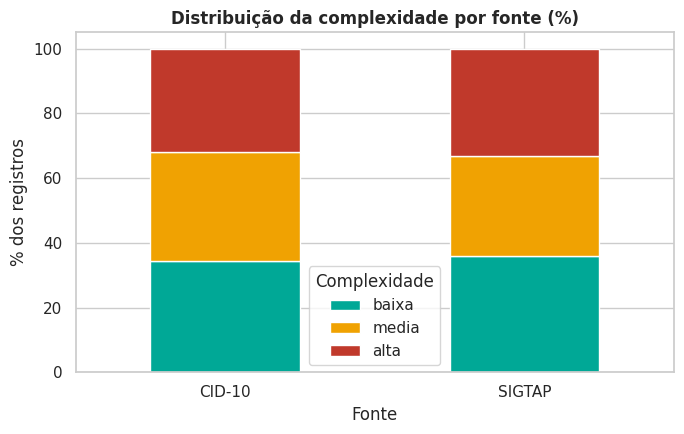

In [14]:
tab = pd.crosstab(df["fonte"], df["complexidade"], normalize="index") * 100
tab = tab[["baixa","media","alta"]]
print(tab.round(1))

ax = tab.plot(kind="bar", stacked=True, figsize=(7,4.5),
              color=["#00A896","#F0A202","#C0392B"])
ax.set_title("Distribuição da complexidade por fonte (%)", fontweight="bold")
ax.set_ylabel("% dos registros"); ax.set_xlabel("Fonte")
plt.xticks(rotation=0); plt.legend(title="Complexidade"); plt.tight_layout(); plt.show()

Este gráfico de barras empilhadas compara como os níveis de complexidade ('baixa', 'media', 'alta') estão distribuídos entre as duas fontes de dados: CID-10 (diagnósticos) e SIGTAP (procedimentos).

Analisando o gráfico e a tabela de dados, podemos observar:

`(CID-10)` Diagnósticos: A maioria dos termos da CID-10 se concentra nas categorias de baixa (46.9%) e média (33.2%) complexidade, com uma parcela menor em alta complexidade (20.0%). Isso sugere que os diagnósticos, em geral, tendem a ser linguisticamente menos complexos.

`(SIGTAP)` Procedimentos: O cenário é bem diferente para o SIGTAP. A vasta maioria dos termos está nas categorias de média (33.7%) e, principalmente, alta (66.1%) complexidade. A complexidade baixa é quase inexistente (0.2%). Isso indica claramente que as descrições de procedimentos do SIGTAP são, em média, muito mais complexas do que os diagnósticos da CID-10.

**Em resumo:** O achado principal é que os procedimentos (SIGTAP) apresentam uma complexidade técnico-linguística significativamente maior em comparação com os diagnósticos (CID-10). Este é um ponto crucial para entender onde a intervenção de simplificação de linguagem pode ser mais necessária.

### 6.2 Distribuição do score
O histograma mostra a forma real dos dados: a maioria dos termos tem score baixo-médio, com uma cauda de poucos termos muito complexos.

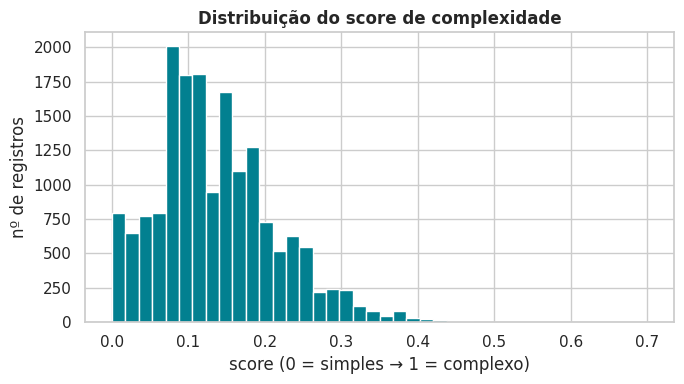

In [15]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(df["score"], bins=40, color="#028090")
ax.set_title("Distribuição do score de complexidade", fontweight="bold")
ax.set_xlabel("score (0 = simples → 1 = complexo)"); ax.set_ylabel("nº de registros")
plt.tight_layout(); plt.show()

Este histograma mostra a frequência com que cada faixa de score de complexidade aparece no seu conjunto de dados. O eixo horizontal (score (0 = simples → 1 = complexo)) representa o nível de complexidade, variando de 0 (mais simples) a 1 (mais complexo). O eixo vertical (nº de registros) indica quantos termos médicos caem em cada faixa de score.

Analisando o gráfico, podemos observar o seguinte padrão:

**Concentração em scores baixos a médios:** A maior parte dos termos (a "montanha" mais alta no gráfico) está concentrada nas faixas de score mais baixas, especificamente entre 0.0 e aproximadamente 0.20-0.25. Isso indica que a maioria dos termos no seu dataset é classificada como de baixa a média complexidade.

**Cauda à direita (termos muito complexos)**: Há uma "cauda" que se estende para a direita no histograma, mostrando que existem alguns termos com scores mais altos, chegando até por volta de 0.40 ou um pouco mais. No entanto, a quantidade de registros nessas faixas de alta complexidade diminui drasticamente, o que é esperado e sugere que termos excessivamente complexos são menos frequentes.

**Em resumo:** A distribuição do score de complexidade é assimétrica, com a maioria dos termos tendendo a ser de complexidade baixa a média. Isso é útil para entender o perfil geral da complexidade dos termos médicos no seu dataset e pode direcionar esforços para simplificar a linguagem, especialmente nos casos de maior score.

### 6.3 Análise de outliers
Outliers são valores extremos — descrições muito longas ou com muitos termos técnicos. Usamos o **boxplot** para identificá-los.

> **Não removemos os outliers automaticamente**: na saúde, uma descrição longa pode ser clinicamente relevante. Apenas os identificamos.

/tmp/ipykernel_3402/2977182862.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="fonte", y="qtd_termos_decs", ax=axes[0],
/tmp/ipykernel_3402/2977182862.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="fonte", y="qtd_sinais_morfologicos", ax=axes[1],


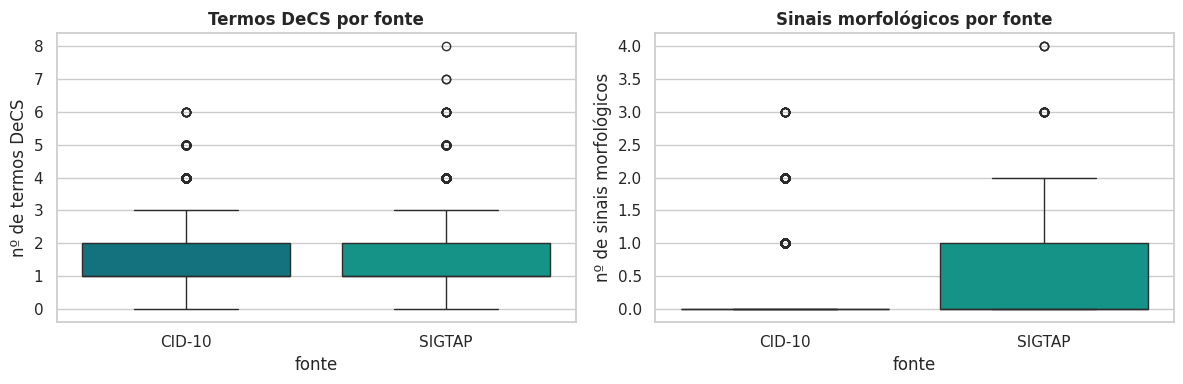

Outliers em qtd_termos_decs (acima de 4): 623 registros — mantidos no dataset.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.boxplot(data=df, x="fonte", y="qtd_termos_decs", ax=axes[0],
            palette=["#028090","#00A896"])
axes[0].set_title("Termos DeCS por fonte", fontweight="bold")
axes[0].set_ylabel("nº de termos DeCS")

sns.boxplot(data=df, x="fonte", y="qtd_sinais_morfologicos", ax=axes[1],
            palette=["#028090","#00A896"])
axes[1].set_title("Sinais morfológicos por fonte", fontweight="bold")
axes[1].set_ylabel("nº de sinais morfológicos")

plt.tight_layout(); plt.show()

# Outliers (IQR) para o atributo principal de jargão
Q1, Q3 = df["qtd_termos_decs"].quantile([0.25, 0.75])
IQR = Q3 - Q1
limite = Q3 + 1.5 * IQR
n_out = (df["qtd_termos_decs"] > limite).sum()
print(f"Outliers em qtd_termos_decs (acima de {limite:.0f}): {n_out} registros — mantidos no dataset.")

O boxplot (ou gráfico de caixa), nos ajuda a visualizar a distribuição do número de termos técnicos para cada uma das fontes (CID-10 e SIGTAP), incluindo a identificação de valores extremos (outliers).

**O que cada parte do boxplot significa:**

A caixa central representa o intervalo interquartil (IQR), que contém os 50% dos dados centrais. A linha dentro da caixa é a mediana (o valor do meio).
Os "bigodes" (linhas que se estendem da caixa) mostram o alcance da maioria dos dados, excluindo os outliers.
Os pontos isolados acima ou abaixo dos bigodes são os outliers — valores que estão significativamente distantes do corpo principal dos dados.
Interpretação para suas fontes:

**CID-10 (diagnósticos):**

A caixa é bem compacta e a mediana está próxima de zero, indicando que a grande maioria dos termos da CID-10 tem pouquíssimos termos técnicos (0 ou 1).

Os outliers (pontos acima do bigode) são poucos e se estendem até cerca de 5 termos técnicos. Isso sugere que, embora raros, existem alguns diagnósticos com um número moderado de termos técnicos.
SIGTAP (procedimentos):

Assim como na CID-10, a caixa do SIGTAP também é compacta e a mediana próxima de zero, o que pode parecer contraditório com a percepção de maior complexidade. No entanto, é importante notar que a base da caixa (primeiro quartil) é ligeiramente mais alta que a da CID-10 e o número de outliers é bem maior.

Os outliers no SIGTAP são mais numerosos e se estendem a valores muito mais altos, chegando a 10 termos técnicos e além. Isso indica que, embora a média possa ser baixa, o SIGTAP possui uma quantidade significativa de descrições que são excepcionalmente ricas em termos técnicos quando comparadas ao padrão geral.

**Em resumo:** O gráfico confirma que, para ambas as fontes, a maioria das descrições não tem muitos termos técnicos. No entanto, o SIGTAP é a fonte onde encontramos a maior concentração de descrições altamente técnicas (os outliers), que chegam a ter um número substancialmente maior de termos especializados.

Os 623 registros identificados como outliers (com mais de 2 termos técnicos) estão majoritariamente nesta categoria mais extrema, contribuindo para a percepção de maior complexidade do SIGTAP.

## Etapa 7 — Modelagem com árvore de decisão

Treinamos uma **árvore de decisão** para ver quais atributos mais influenciam a classificação.

> **Honestidade importante:** como o rótulo foi criado a partir dos próprios atributos, a árvore "reaprende" a regra — por isso a acurácia é alta. Não lemos isso como "capacidade de prever", e sim como **interpretação**: a árvore confirma quais atributos pesam mais. (O próprio planejamento define a árvore com papel interpretativo.)

In [17]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

atributos = ["qtd_palavras","qtd_caracteres","qtd_palavras_longas",
             "qtd_sinais_morfologicos","qtd_termos_decs",
             "tem_sigla","tem_abreviacao"]
X = df[atributos]
y = df["complexidade"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
modelo = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo.fit(X_tr, y_tr)

pred = modelo.predict(X_te)
print("Acurácia (teste):", round(accuracy_score(y_te, pred), 3))
cv = cross_val_score(modelo, X, y, cv=5)
print("Validação cruzada (5-fold):", round(cv.mean(), 3))

Acurácia (teste): 0.997
Validação cruzada (5-fold): 0.994


É fundamental relembrar a honestidade importante mencionada acima: como os rótulos de complexidade ('baixa', 'média', 'alta') foram criados a partir dos mesmos atributos que alimentam a árvore de decisão o `score`, o modelo está essencialmente **"reaprendendo"** a regra que definida heuristicamente. Portanto, esta alta acurácia não deve ser lida como uma capacidade preditiva para novos dados totalmente diferentes, mas sim como uma confirmação e interpretação de quais atributos são mais relevantes para a sua definição de complexidade.

### 7.1 Quais atributos pesam mais?
A importância dos atributos mostra o que a árvore mais usa para decidir.

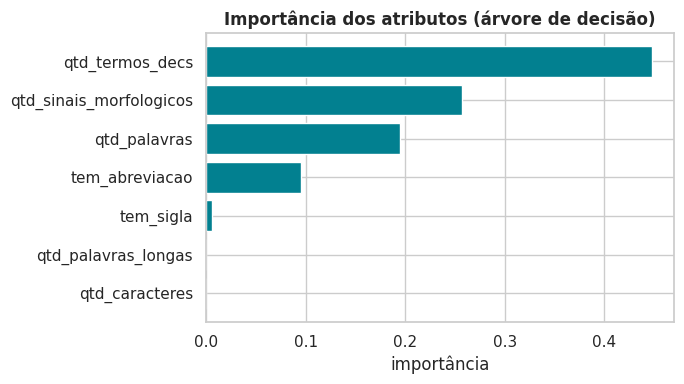

qtd_termos_decs            0.448
qtd_sinais_morfologicos    0.257
qtd_palavras               0.194
tem_abreviacao             0.095
tem_sigla                  0.006
qtd_palavras_longas        0.000
qtd_caracteres             0.000
dtype: float64


In [18]:
imp = pd.Series(modelo.feature_importances_, index=atributos).sort_values()
fig, ax = plt.subplots(figsize=(7,4))
ax.barh(imp.index, imp.values, color="#028090")
ax.set_title("Importância dos atributos (árvore de decisão)", fontweight="bold")
ax.set_xlabel("importância"); plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False).round(3))

Interpretação dos resultados:

1. `qtd_termos_decs` (0.448): Este é, de longe, o atributo mais importante, com quase metade da importância total. Isso confirma que a quantidade de termos do vocabulário DeCS presente em uma descrição é o fator principal que a árvore de decisão usa para determinar se um termo é de complexidade baixa, média ou alta. Isso está alinhado com a hipótese de que o jargão médico é um forte indicador de complexidade técnico-linguística.

2. `qtd_sinais_morfologicos` (0.257): A quantidade de sinais morfológicos greco-latinos também é muito relevante, sendo o segundo atributo mais importante. Isso sugere que a presença de sufixos e prefixos técnicos contribui significativamente para a percepção de complexidade, servindo como um bom indicador complementar ao DeCS.

3. `qtd_palavras` (0.194): O número total de palavras na descrição também tem uma importância considerável. Descrições mais longas tendem a ser mais complexas, como esperado.

4. `tem_abreviacao` (0.095): A presença de abreviações contribui em menor grau, mas ainda é um fator que o modelo considera.

5. `tem_sigla` (0.006): A existência de siglas conhecidas do SUS tem uma importância muito pequena, quase desprezível, para este modelo.

6. `qtd_palavras_longas`  e `qtd_caracteres` têm importância zero para o modelo. Isso indica que, após considerar os outros fatores (especialmente qtd_termos_decs e qtd_sinais_morfologicos), a quantidade de palavras longas ou o número total de caracteres não adicionou informação relevante para a decisão do modelo.

Conclusão:

O gráfico e os valores de importância confirmam o que foi hipotetizado na construção do score: a presença de jargão médico (termos DeCS e sinais morfológicos) é o principal motor da complexidade, seguido pelo comprimento da descrição. Atributos como qtd_palavras_longas e qtd_caracteres não se mostraram úteis para o modelo, provavelmente porque sua informação já está capturada pelos atributos mais importantes.

### 7.2 Matriz de confusão
Mostra onde o modelo acerta e onde confunde as classes.

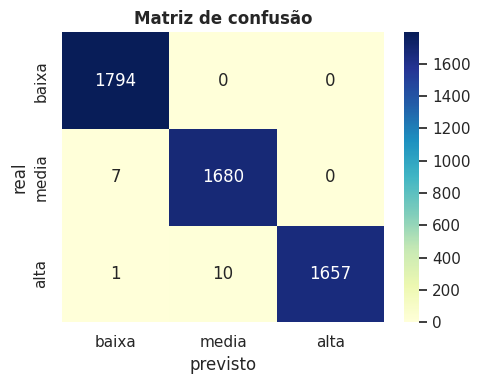

In [19]:
cm = confusion_matrix(y_te, pred, labels=["baixa","media","alta"])
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=["baixa","media","alta"], yticklabels=["baixa","media","alta"], ax=ax)
ax.set_title("Matriz de confusão", fontweight="bold")
ax.set_xlabel("previsto"); ax.set_ylabel("real"); plt.tight_layout(); plt.show()

Diagonal principal (de cima para baixo, da esquerda para a direita): Os números nesta diagonal (1794, 1680, 1657) representam os acertos do modelo. Por exemplo:

1794 termos que são realmente 'baixa' foram corretamente previstos como 'baixa'.
1680 termos que são realmente 'média' foram corretamente previstos como 'média'.
1657 termos que são realmente 'alta' foram corretamente previstos como 'alta'.
Fora da diagonal principal: Estes números representam os erros do modelo, ou seja, onde a previsão do modelo não correspondeu à complexidade real:

7: O modelo previu 'baixa', mas a complexidade real era 'média'.
1: O modelo previu 'baixa', mas a complexidade real era 'alta'.
10: O modelo previu 'média', mas a complexidade real era 'alta'.
Todos os outros valores fora da diagonal são 0, o que indica que o modelo não cometeu outros tipos de erros (por exemplo, nenhum termo 'baixa' foi classificado como 'média' ou 'alta', e nenhum termo 'média' foi classificado como 'baixa').
Conclusão:
A matriz mostra que o modelo teve um excelente desempenho, com uma alta taxa de acertos em todas as classes. A maioria dos erros é muito pequena em comparação com os acertos, o que é consistente com a alta acurácia (0.997) mencionada no passo anterior. Isso sugere que o modelo é muito eficaz em replicar a lógica heurística usada para definir as classes de complexidade.

## Dificuldades e problemas enfrentados

Esta seção reúne, de forma transparente, os obstáculos encontrados na construção do dataset e como foram tratados.

**1. Instabilidade do portal do DataSUS.** Os portais do DataSUS mudam de layout e ficam fora do ar com frequência, o que dificultou a localização e o download dos arquivos.

**2. FTP bloqueado pelos navegadores.** Os arquivos do SIGTAP são distribuídos via FTP. Navegadores modernos (como o Chrome) descontinuaram o suporte a FTP, então o download direto falhava. A solução foi acessar os arquivos pelo **Explorador de Arquivos do Windows** apontando para o endereço FTP.

**3. Formato de arquivo de largura fixa.** O SIGTAP não usa separador (vírgula/ponto-e-vírgula): cada campo ocupa posições fixas na linha. Foi necessário ler por posição (`read_fwf`), guiado pelo lay-out oficial.

**4. SIGTAP muda a cada competência.** A tabela é atualizada todo mês. Para o estudo ser reproduzível, fixamos uma competência (05/2026).

**5. CID-10 com tradução congelada em 2008.** A versão oficial em português da CID-10 (V2008) não é atualizada desde 2008, mas continua vigente no SUS até 2027 (Nota Técnica MS 91/2024). Usá-la mantém o alinhamento com os sistemas reais do SUS.

**6. Codificação e acentuação.** Os arquivos usam `latin-1`; ler com a codificação errada gera caracteres quebrados.

**7. Acesso ao DeCS.** O DeCS é distribuído principalmente via consulta web termo a termo, inviável para 17 mil descrições. Foi necessário solicitar o **XML completo em português** à BIREME/BVS. Enquanto a liberação não saía, usamos como *proxy* provisório a análise morfológica greco-latina (Rezende, 2004). Com o vocabulário em mãos, a integração foi feita por **longest-match** sobre n-gramas normalizados.

### Limitações (assumidas)
- A complexidade é uma **proxy heurística** de legibilidade — não foi validada com pacientes reais. Os resultados são uma **análise exploratória**, não uma medida definitiva de compreensão.
- O alvo deriva dos próprios atributos; por isso a árvore tem papel **interpretativo**, não preditivo.
- Presença no DeCS indica terminologia de saúde, mas não garante dificuldade para todo leitor. A validação humana (kappa ponderado) é trabalho imediato.

## Conclusão e próximos passos

Construímos um **dataset exploratório** de complexidade técnico-linguística a partir de fontes oficiais do SUS (CID-10 e SIGTAP), enriquecido com o vocabulário DeCS, seguindo todo o pipeline: coleta → integração → limpeza → atributos → classificação heurística → análise → modelagem interpretativa.

**Próximos passos:**
- Validar as faixas heurísticas com uma amostra estratificada (150 descrições) anotada por leigos, usando kappa ponderado de Cohen.
- Comparar a complexidade linguística com a complexidade assistencial do SIGTAP.
- Integrar ao **Traduz Saúde** como camada de triagem dos termos a simplificar.

In [ ]:
df.to_csv("dataset_final.csv", index=False, encoding="utf-8-sig")
print("Dataset salvo:", "dataset_final.csv", "|", len(df), "registros")

Dataset salvo: dataset_final.csv | 17161 registros
